# นำเข้า Libraries


In [19]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay

# โหลดข้อมูล
df = pd.read_csv('tech_mental_health_burnout.csv')
print("Shape of Data:", df.shape)

Shape of Data: (150000, 25)


# โหลดข้อมูลและวิเคราะห์เบื้องต้น (EDA)

C:\Users\MY_PC\AppData\Local\Temp\ipykernel_15496\3935468880.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='burnout_level', data=df, order=['Low', 'Moderate', 'High'], ax=axes[0], palette='viridis')


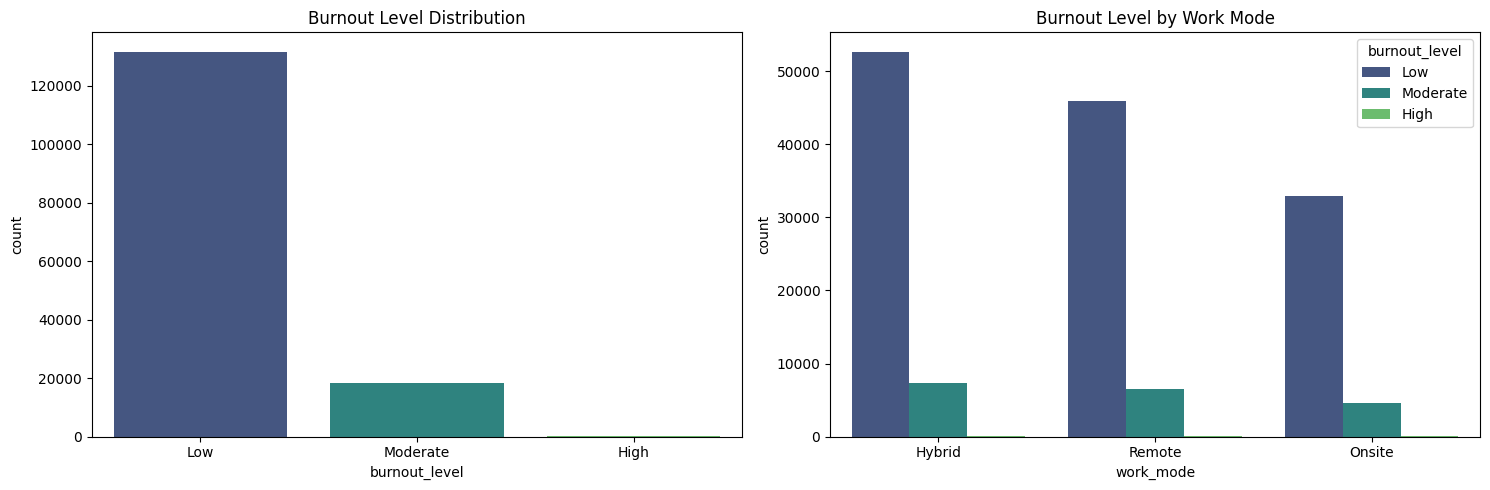

In [20]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# 1. การกระจายตัวของ Target
sns.countplot(x='burnout_level', data=df, order=['Low', 'Moderate', 'High'], ax=axes[0], palette='viridis')
axes[0].set_title('Burnout Level Distribution')

# 2. เปรียบเทียบรูปแบบการทำงาน (Work Mode) กับความเครียด
sns.countplot(x='work_mode', hue='burnout_level', data=df, ax=axes[1], palette='viridis')
axes[1].set_title('Burnout Level by Work Mode')

plt.tight_layout()
plt.show()

### การตรวจสอบ Missing values และการกระจายตัวของฟีเจอร์ตัวเลข

เกณฑ์การให้คะแนนต้องการให้เห็นว่าเข้าใจข้อมูลจริง — จึงตรวจสอบค่าที่หายไป และดู **distribution** ของฟีเจอร์ตัวเลขสำคัญบางส่วน

จำนวนค่าที่หายไปต่อคอลัมน์ (ทุกคอลัมน์):
age                        0
gender                     0
job_role                   0
experience_years           0
company_size               0
work_mode                  0
work_hours_per_week        0
overtime_hours             0
meetings_per_day           0
deadlines_missed           0
job_satisfaction           0
manager_support            0
work_life_balance          0
sleep_hours                0
physical_activity_days     0
screen_time_hours          0
caffeine_intake            0
social_support_score       0
has_therapy                0
stress_level               0
anxiety_score              0
depression_score           0
burnout_score              0
burnout_level              0
seeks_professional_help    0

สรุป: ไม่มี missing values — ไม่ต้อง impute ในขั้นตอนนี้ (หากอนาคตมีข้อมูลจริงที่มีช่องว่าง ควรกำหนดกลยุทธ์เช่น median/mode ตามชนิดตัวแปร)


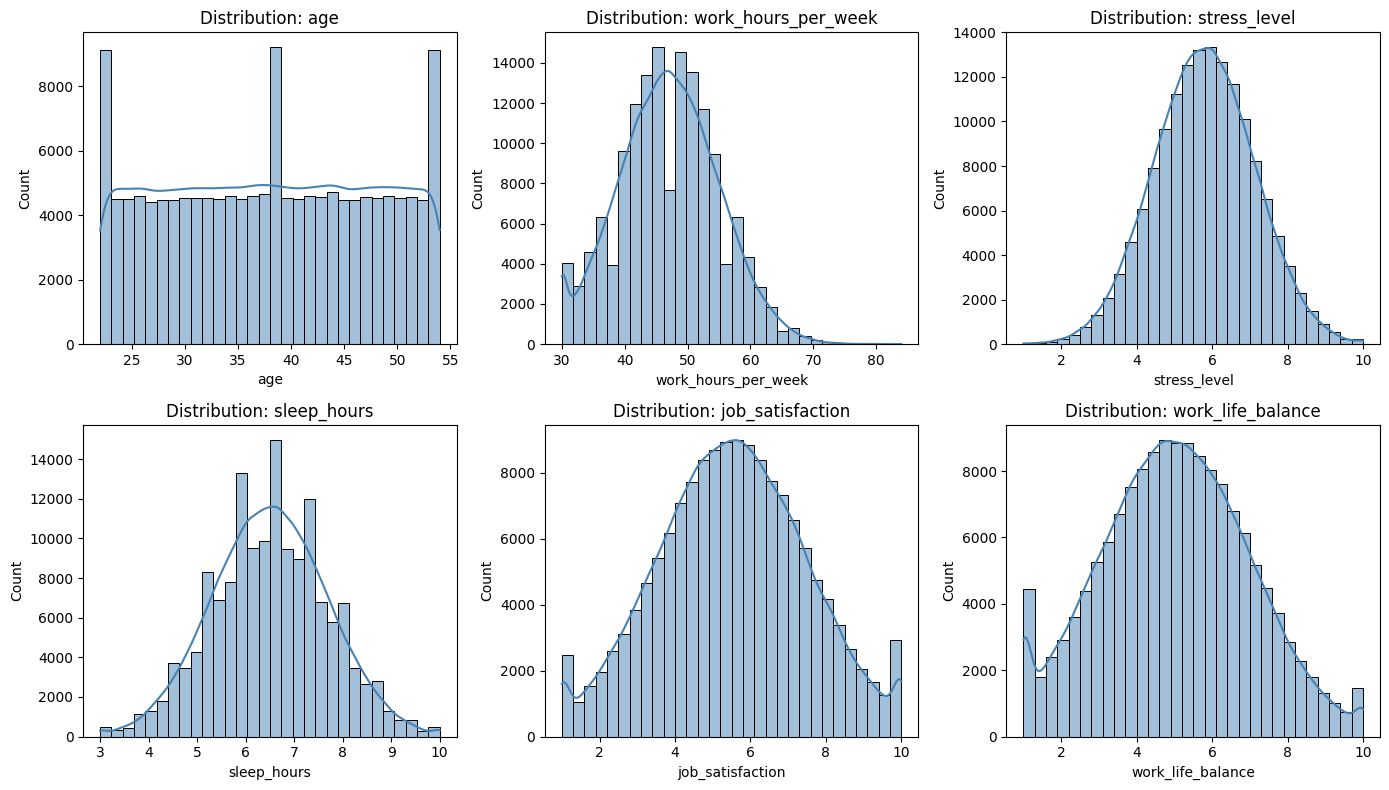

In [21]:
# ตรวจสอบ missing values
missing = df.isnull().sum()
print("จำนวนค่าที่หายไปต่อคอลัมน์ (ทุกคอลัมน์):")
print(missing.to_string())
if missing.sum() == 0:
    print("\nสรุป: ไม่มี missing values — ไม่ต้อง impute ในขั้นตอนนี้ (หากอนาคตมีข้อมูลจริงที่มีช่องว่าง ควรกำหนดกลยุทธ์เช่น median/mode ตามชนิดตัวแปร)")
else:
    print("\nพบ missing — ควรกำหนดกลยุทธ์ impute ต่อคอลัมน์ (ตัวเลข: median/mean, หมวด: mode หรือ 'Unknown')")

# Distribution ของฟีเจอร์ตัวเลขสำคัญ (ตัวแทน)
num_cols_eda = [
    "age", "work_hours_per_week", "stress_level", "sleep_hours",
    "job_satisfaction", "work_life_balance",
]
existing = [c for c in num_cols_eda if c in df.columns]
n = len(existing)
ncols = 3
nrows = int(np.ceil(n / ncols))
fig, axes = plt.subplots(nrows, ncols, figsize=(14, 4 * nrows))
axes = np.atleast_1d(axes).flatten()
for i, col in enumerate(existing):
    sns.histplot(df[col], kde=True, ax=axes[i], color="steelblue", bins=30)
    axes[i].set_title(f"Distribution: {col}")
for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)
plt.tight_layout()
plt.show()

# สร้าง Pipeline

### เหตุผลในการเลือก Preprocessing

- **StandardScaler สำหรับฟีเจอร์ตัวเลข**: ฟีเจอร์มีหน่วยและช่วงค่าต่างกัน (เช่น ชั่วโมงทำงานกับคะแนน 1–10) การปรับให้มีค่าเฉลี่ยใกล้ศูนย์และสเกลใกล้เคียงกันช่วยให้โมเดลที่อาศัยระยะทางในปริภูมิฟีเจอร์ (รวมถึงต้นไม้ที่แบ่งจากเงื่อนไขบนค่าตัวเลข) ทำงานเสถียรขึ้นเมื่ออยู่ใน Pipeline เดียวกับขั้นตอนถัดไป

- **OneHotEncoder สำหรับตัวแปรเชิงหมวดหมู่**: ตัวแปรเช่น เพศ ตำแหน่งงาน ไม่มีลำดับเชิงตัวเลขที่สมเหตุสมผล การใช้ one-hot หลีกเลี่ยงการกำหนดลำดับเทียม และ `handle_unknown='ignore'` ช่วยเมื่อมีค่าหมวดใหม่ที่ไม่เคยเห็นตอน train (สอดคล้องการนำไป deploy)

In [22]:
# 1. จัดการ Data Leakage (ลบคอลัมน์คำตอบแฝง)
# ใน Kaggle เขาไม่ได้ลบ burnout_score ออก ซึ่งถือว่าผิดหลักการ เพราะ score คือตัวบอก level ตรงๆ
X = df.drop(columns=['burnout_level', 'burnout_score', 'seeks_professional_help'])
y = df['burnout_level']

# 2. แบ่งข้อมูล Train/Test
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# 3. แยกประเภทคอลัมน์
numeric_features = X.select_dtypes(include=['int64', 'float64']).columns.tolist()
categorical_features = X.select_dtypes(include=['object']).columns.tolist()

# 4. สร้าง Preprocessor (แทนที่ get_dummies ของเดิม)
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numeric_features),
        ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_features)
    ])

# 5. ประกอบร่างเป็น Pipeline
pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', RandomForestClassifier(random_state=42, class_weight='balanced'))
])
print("สร้าง Pipeline สำเร็จ เตรียมพร้อมสำหรับการเทรน!")

สร้าง Pipeline สำเร็จ เตรียมพร้อมสำหรับการเทรน!


### การเลือกอัลกอริทึม การจูน hyperparameter และเมตริก

**ทำไมถึงเลือก Random Forest**
- ข้อมูลมีทั้งตัวเลขและตัวแปรเชิงหมวดหมู่ (หลังผ่าน preprocessing ใน Pipeline) และอาจมีความไม่สมดุลของคลาส — Random Forest รองรับการผสมฟีเจอร์แบบนี้ได้ดี และใช้ `class_weight='balanced'` ช่วยถ่วงน้ำหนักคลาสที่ปรากฏน้อยกว่าได้โดยไม่ต้องดาวน์แซมเปิลข้อมูลทิ้ง
- อ่านคำอธิบายเชิงความสำคัญของฟีเจอร์ได้จาก `feature_importances_` ซึ่งสอดคล้องกับการนำไปอธิบายในแอป

**GridSearchCV กับ k-fold**
- ใช้ `GridSearchCV(..., cv=3)` คือการทำ **3-fold cross-validation** บนชุด train สำหรับทุกชุดพารามิเตอร์ที่กำหนด แล้วเลือกชุดที่ให้คะแนนตาม `scoring` สูงสุด — ลดความเสี่ยงที่จะจับโอกาสกับการแบ่ง train/test เพียงครั้งเดียว

**เมตริกที่เหมาะสม (มากกว่า accuracy อย่างเดียว)**
- ปัญหา 3 คลาสและอาจมีความไม่สมดุลของคลาสได้ จึงใช้ **`f1_weighted`** เป็นเกณฑ์ใน `GridSearchCV` (ถ่วง F1 ตามสัดส่วนคลาส) แทนการใช้ accuracy เพียงอย่างเดียว ซึ่งอาจสูงเกินจริงเมื่อคลาสใหญ่ dominate
- `classification_report` แสดง **precision / recall / f1-score ต่อคลาส** — สำคัญเวลาต้องการจับคลาสที่เสี่ยง (เช่น High) ให้ได้ recall สูงแม้แลกด้วย precision บ้าง

**ข้อจำกัดในการตีความ**
- โมเดลนี้เป็นเครื่องมือช่วยประเมินเบื้องต้นในการศึกษา ไม่ใช่การวินิจฉัยทางการแพทย์ ผลควรใช้ร่วมกับบริบทจริงในที่ทำงาน

In [23]:
# กำหนดค่าพารามิเตอร์ที่ต้องการจูน
# USE_FULL_GRID=False → กริดกะทัดรัด ไฟล์ .pkl มักใต้ 100 MB (เหมาะกับ GitHub)
# USE_FULL_GRID=True  → กริดแบบเดิม ไฟล์อาจ ~100 MB ขึ้นไป
USE_FULL_GRID = False
param_grid_full = {
    'classifier__n_estimators': [50, 100],
    'classifier__max_depth': [10, 20, None],
}
param_grid_compact = {
    'classifier__n_estimators': [40, 60],
    'classifier__max_depth': [10, 12, 16],
    'classifier__min_samples_leaf': [2, 4],
}
param_grid = param_grid_full if USE_FULL_GRID else param_grid_compact

print("กำลังค้นหาพารามิเตอร์ที่ดีที่สุดด้วย GridSearchCV...")
# ใช้ cv=3 เพื่อความรวดเร็วในการรันบน Colab (ถ้ามีเวลาเปลี่ยนเป็น cv=5 ได้ครับ)
grid_search = GridSearchCV(pipeline, param_grid, cv=3, scoring='f1_weighted', n_jobs=-1)
grid_search.fit(X_train, y_train)

print(f"พารามิเตอร์ที่ดีที่สุด: {grid_search.best_params_}")

กำลังค้นหาพารามิเตอร์ที่ดีที่สุดด้วย GridSearchCV...
พารามิเตอร์ที่ดีที่สุด: {'classifier__max_depth': 20, 'classifier__n_estimators': 100}


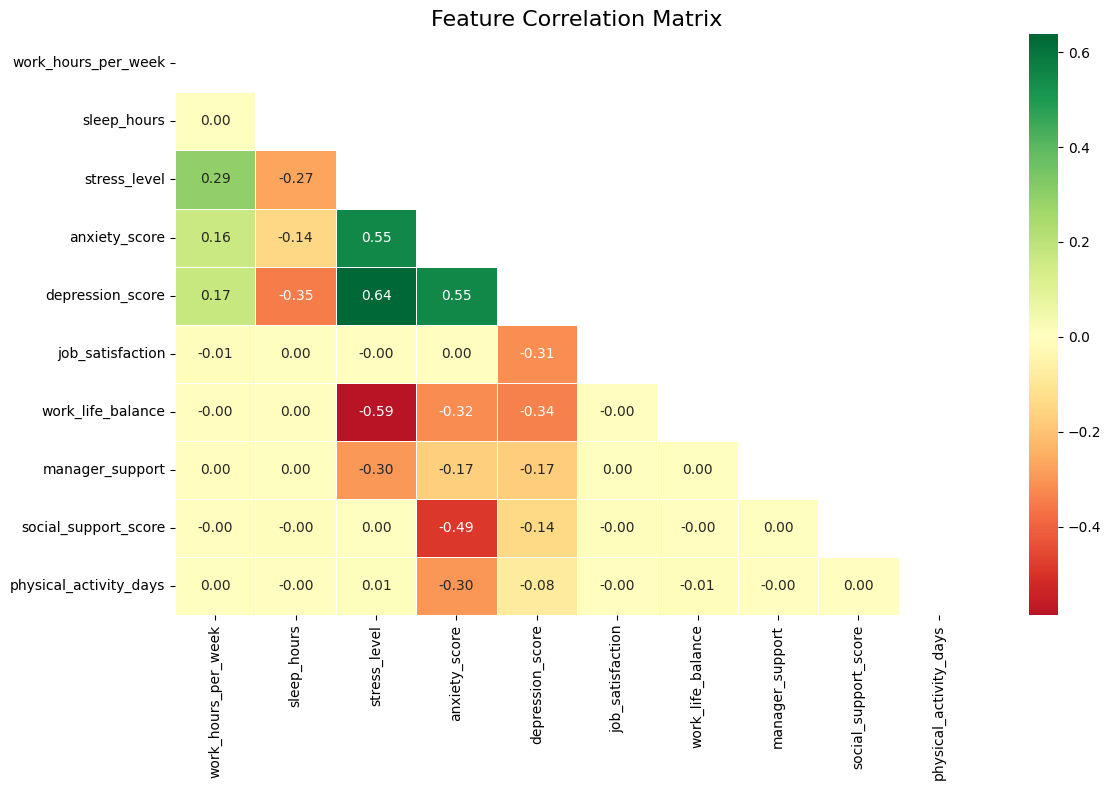

In [24]:
df = pd.read_csv('tech_mental_health_burnout.csv')

num_cols = ['work_hours_per_week','sleep_hours','stress_level','anxiety_score',
            'depression_score','job_satisfaction','work_life_balance',
            'manager_support','social_support_score','physical_activity_days']

corr_matrix = df[num_cols].corr()

# 2. สร้าง Mask ซ่อนกราฟครึ่งบน (เทคนิคโปร)
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))

plt.figure(figsize=(12, 8))
sns.heatmap(corr_matrix,
            mask=mask,
            annot=True,
            fmt='.2f',
            cmap='RdYlGn',   # ใช้โทนสี แดง-เหลือง-เขียว ตามที่คุณชอบ
            center=0,
            linewidths=0.5)

plt.title('Feature Correlation Matrix', fontsize=16)
plt.tight_layout()
plt.show()

--- Classification Report ---
              precision    recall  f1-score   support

        High       0.00      0.00      0.00        13
         Low       0.95      0.97      0.96     26324
    Moderate       0.73      0.61      0.67      3663

    accuracy                           0.93     30000
   macro avg       0.56      0.53      0.54     30000
weighted avg       0.92      0.93      0.92     30000


--- Confusion Matrix (rows=จริง, cols=ทำนาย) ---
            Low  Moderate  High
Low       25505       819     0
Moderate   1411      2251     1
High          0        13     0


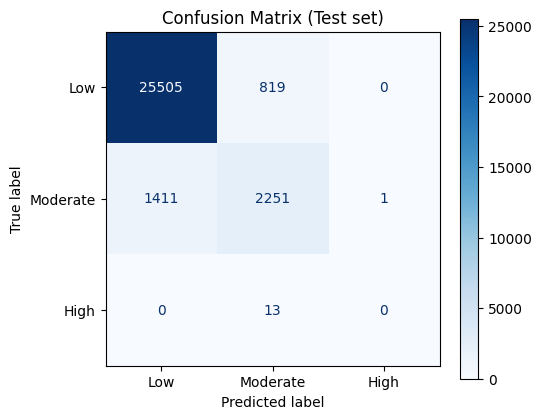

C:\Users\MY_PC\AppData\Local\Temp\ipykernel_15496\3085134543.py:33: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Importance', y='Feature', data=importance_df, palette='Reds_r')


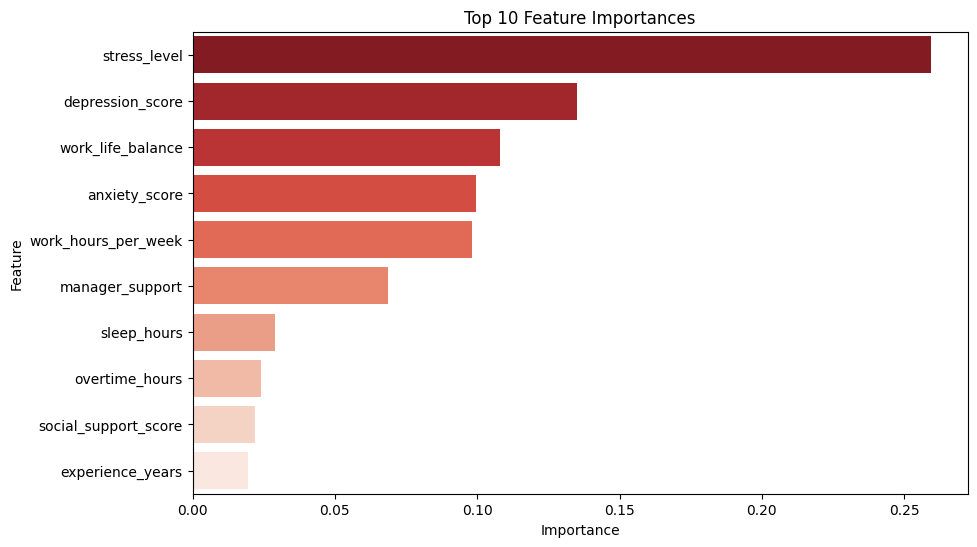


บันทึกไฟล์ 'burnout_model.pkl' เรียบร้อยแล้ว


In [25]:
# 1. การประเมินผลบนชุดทดสอบ
y_pred = grid_search.predict(X_test)
print("--- Classification Report ---")
print(classification_report(y_test, y_pred))

# Confusion Matrix (เทียบกับ accuracy อย่างเดียว — เห็นว่าคลาสไหนสับสนกัน)
labels_order = ["Low", "Moderate", "High"]
cm = confusion_matrix(y_test, y_pred, labels=labels_order)
print("\n--- Confusion Matrix (rows=จริง, cols=ทำนาย) ---")
print(pd.DataFrame(cm, index=labels_order, columns=labels_order))
fig, ax = plt.subplots(figsize=(5.5, 4.5))
ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=labels_order).plot(ax=ax, cmap="Blues", colorbar=True)
plt.title("Confusion Matrix (Test set)")
plt.tight_layout()
plt.show()

# 2. การดึง Feature Importance จาก Pipeline
best_model = grid_search.best_estimator_
rf_model = best_model.named_steps['classifier']

# ดึงชื่อคอลัมน์หลังจากผ่านการทำ OneHotEncoding
cat_encoder = best_model.named_steps['preprocessor'].named_transformers_['cat']
cat_features_out = cat_encoder.get_feature_names_out(categorical_features).tolist()
all_feature_names = numeric_features + cat_features_out

# 3. พลตกราฟ Feature Importance (Top 10)
importance_df = pd.DataFrame({
    'Feature': all_feature_names,
    'Importance': rf_model.feature_importances_
}).sort_values(by='Importance', ascending=False).head(10)

plt.figure(figsize=(10, 6))
sns.barplot(x='Importance', y='Feature', data=importance_df, palette='Reds_r')
plt.title('Top 10 Feature Importances')
plt.show()

# 4. บันทึกโมเดล (บีบอัด zlib — โหลดด้วย joblib.load เหมือนเดิม)
joblib.dump(best_model, 'burnout_model.pkl', compress=('zlib', 3))
print("\nบันทึกไฟล์ 'burnout_model.pkl' เรียบร้อยแล้ว")

### การแปลผลเชิงปฏิบัติ (ไม่ใช่แค่ตัวเลข)

- **Precision / Recall ต่อคลาส**: ถ้าเป้าหมายคือ **ลดการพลาดคนที่เสี่ยงสูง (High)** อาจให้ความสำคัญกับ **recall ของคลาส High** มากกว่า accuracy รวม — เพราะพลาดเคส High อาจทำให้ไม่ได้รับการช่วยเหลือทันเวลา
- **Confusion Matrix**: บอกว่าโมเดลสับสนระหว่างคลาสใดบ้าง (เช่น Moderate กับ High) ซึ่งใช้ตัดสินใจว่าปรับ threshold หรือเก็บข้อมูลเพิ่มทางใด
- **ในองค์กรจริง**: ใช้ผลเป็น **สัญญาณเสริม** ร่วมกับนโยบาย HR/สุขภาพ ไม่ใช่คำตัดสินคนเดียว — สอดคล้อง disclaimer ในแอป Streamlit

### โบนัส: เปรียบเทียบโมเดลแบบเป็นระบบ (Random Forest vs Gradient Boosting vs SVM)

ในชุดข้อมูลนี้มี **ตัวแปรผสมตัวเลข–หมวดหมู่จำนวนมาก** และ **คลาสไม่สมดุล** (โดยเฉพาะคลาส High มีจำนวนน้อย) ดังนั้นการเลือกอัลกอริทึมควรดูทั้ง **คะแนน F1 แบบ weighted** (ถ่วงตามขนาดคลาส) และ **ความเร็วในการฝึก/ทำนาย**

- **Random Forest**: ทนข้อมูลผสมได้ดี ไม่ต้องสมมติรูปแบบเชิงเส้น มี `class_weight='balanced'` ช่วยถ่วงคลาสหายาก — เหมาะเป็นฐานอ้างอิง
- **HistGradientBoosting** (gradient boosting แบบต้นไม้ฮิสโตแกรม): เรียนรู้ความสัมพันธ์ที่ไม่เป็นเชิงเส้นได้ละเอียดกว่าในหลายงาน แต่เสี่ยง **overfit** หรือใช้เวลาฝึกมากขึ้นถ้าไม่จูนระมัดระวัง
- **SVM แบบเส้น (LinearSVC)**: ในสเกลข้อมูลจริง (แสนแถว) การใช้ **RBF SVM** บนทั้งชุด train มักไม่สมเหตุสมผลเรื่องเวลา จึงใช้ **SVM เชิงเส้น** หลัง scaling ซึ่งแข่งกับต้นไม้บนข้อมูลที่มี **interaction ซับซ้อน** ได้ยากกว่า

รันเซลล์ถัดไปหลังเซลล์ที่สร้าง `X_train`, `X_test`, `y_train`, `y_test` และ `preprocessor` แล้ว — จะได้ตารางเปรียบเทียบ CV และผลบน test set พร้อมข้อความสรุป

In [26]:
from sklearn.ensemble import HistGradientBoostingClassifier
from sklearn.svm import LinearSVC
from sklearn.model_selection import cross_val_score
from sklearn.metrics import f1_score, accuracy_score

# ใช้ preprocessor เดียวกับ Pipeline เดิม (ต้องรันเซลล์แยกฟีเจอร์แล้ว)
pipelines = {
    "RandomForest": Pipeline([
        ("preprocessor", preprocessor),
        ("classifier", RandomForestClassifier(
            random_state=42, class_weight="balanced", n_estimators=100, max_depth=20, n_jobs=-1
        )),
    ]),
    "HistGradientBoosting": Pipeline([
        ("preprocessor", preprocessor),
        ("classifier", HistGradientBoostingClassifier(
            random_state=42, class_weight="balanced", max_iter=200, max_depth=12, learning_rate=0.08
        )),
    ]),
    "LinearSVC (SVM เชิงเส้น)": Pipeline([
        ("preprocessor", preprocessor),
        ("classifier", LinearSVC(class_weight="balanced", dual=False, max_iter=4000, random_state=42)),
    ]),
}

rows = []
for name, pipe in pipelines.items():
    f1_cv = cross_val_score(pipe, X_train, y_train, cv=3, scoring="f1_weighted", n_jobs=-1)
    pipe.fit(X_train, y_train)
    y_hat = pipe.predict(X_test)
    rows.append({
        "Model": name,
        "F1_weighted (CV mean)": f1_cv.mean(),
        "F1_weighted (CV std)": f1_cv.std(),
        "F1_weighted (test)": f1_score(y_test, y_hat, average="weighted"),
        "Accuracy (test)": accuracy_score(y_test, y_hat),
    })

compare_df = pd.DataFrame(rows).sort_values("F1_weighted (test)", ascending=False)
print("=== เปรียบเทียบโมเดล (ชุดเดียวกัน แบ่ง train/test เดิม) ===\n")
print(compare_df.to_string(index=False))

best_name = compare_df.iloc[0]["Model"]
print(f"\n--- สรุปสั้นๆ ---\nโมเดลที่ได้ F1_weighted (test) สูงสุดในรอบนี้: {best_name}")
print(
    "Random Forest มักเสถียรบนข้อมูลผสมหลายมิติ; "
    "Gradient Boosting อาจดึง pattern ละเอียดได้แต่ต้องระวัง overfit/เวลา; "
    "Linear SVM เร็วแต่สมมติเส้นแบ่งแบบเชิงเส้นในปริภูมิที่ถูกสเกลแล้ว — จึงอาจไม่ชนะต้นไม้เมื่อขอบเขตคลาสโค้งหรือมี interaction สูง"
)

=== เปรียบเทียบโมเดล (ชุดเดียวกัน แบ่ง train/test เดิม) ===

                   Model  F1_weighted (CV mean)  F1_weighted (CV std)  F1_weighted (test)  Accuracy (test)
LinearSVC (SVM เชิงเส้น)               0.924032              0.000359            0.924356         0.920567
            RandomForest               0.921684              0.001206            0.922198         0.925200
    HistGradientBoosting               0.885750              0.003411            0.882463         0.865533

--- สรุปสั้นๆ ---
โมเดลที่ได้ F1_weighted (test) สูงสุดในรอบนี้: LinearSVC (SVM เชิงเส้น)
Random Forest มักเสถียรบนข้อมูลผสมหลายมิติ; Gradient Boosting อาจดึง pattern ละเอียดได้แต่ต้องระวัง overfit/เวลา; Linear SVM เร็วแต่สมมติเส้นแบ่งแบบเชิงเส้นในปริภูมิที่ถูกสเกลแล้ว — จึงอาจไม่ชนะต้นไม้เมื่อขอบเขตคลาสโค้งหรือมี interaction สูง
